# Movie Success Prediction: Modeling, Scenario Simulation, and Decision Support

# Modeling Overview

This notebook focuses on the machine learning modeling and predictive analytics stages of the movie success prediction project.

Using the cleaned and preprocessed movie dataset generated during the exploratory data analysis (EDA) phase, multiple supervised machine learning models are developed and evaluated to predict whether a movie will achieve commercial success.

The notebook includes:

- Historical actor and director feature engineering
- Actor star power estimation using unsupervised clustering
- Genre encoding and production feature preparation
- Temporal train, validation, and test splitting
- Supervised classification modeling
- Model comparison and evaluation
- Hyperparameter tuning and feature refinement
- Ensemble learning approaches
- Scenario simulation and decision-support analysis

Several machine learning algorithms are explored throughout the modeling process, including Logistic Regression, Random Forest, Gradient Boosting, XGBoost, and stacking ensemble models.

In the final stages of the notebook, the predictive framework is extended into a scenario simulation system that allows hypothetical movie projects to be evaluated dynamically using historical actor, director, genre, runtime, and budget information.

In [51]:
!git clone https://github.com/ekuzminla/Movie-Success-Prediction.git

Cloning into 'Movie-Success-Prediction'...
remote: Enumerating objects: 14, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 14 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (14/14), 5.39 MiB | 9.88 MiB/s, done.


In [52]:
%cd Movie-Success-Prediction

/content/Movie-Success-Prediction/Movie-Success-Prediction/Movie-Success-Prediction


In [53]:
import pandas as pd

In [54]:
movie_budget = pd.read_csv('data/movies_budget.csv')

In [55]:
movie_principals = pd.read_csv('data/movie_principals.csv')

In [56]:
movie_principals["category"] = movie_principals["category"].replace({
    "actress": "actor"
})

In [57]:
movie_people_filtered = pd.read_csv('data/movie_people.csv')

In [58]:
movie_ratings = pd.read_csv('data/movie_ratings.csv')

In [59]:
movie_titles = pd.read_csv('data/movie_titles.csv', index_col=0).reset_index(drop=True)

In [60]:
# filter out not movies
movie_titles = movie_titles[movie_titles["titleType"] == "movie"]

In [61]:
movies = movie_budget.merge(
    movie_titles,
    left_on="imdb_id",
    right_on="tconst",
    how="left"
)

movies = movies.merge(
    movie_ratings,
    on="tconst",
    how="left"
)

In [62]:
# Remove Unnecessary Index Column

movies = movies.drop(columns=["Unnamed: 0"])

# Remove Duplicate Movie Identifier

movies = movies.drop(columns=["tconst"])

movies = movies.drop(columns=[
    "originalTitle",
    "titleType",
    "isAdult",
    "startYear",
    "endYear"
])

movies["runtimeMinutes"] = pd.to_numeric(movies["runtimeMinutes"], errors="coerce")

movies = movies.rename(columns={
    "primaryTitle": "title",
    "runtimeMinutes": "runtime",
    "averageRating": "rating"
})

movies = movies.dropna(subset=[
    "title",
    "genres",
    "runtime",
    "rating",
    "numVotes"
])

In [63]:
# Check result

movies.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8215 entries, 0 to 8987
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   imdb_id   8215 non-null   object 
 1   budget    8215 non-null   int64  
 2   revenue   8215 non-null   int64  
 3   year      8215 non-null   int64  
 4   title     8215 non-null   object 
 5   runtime   8215 non-null   float64
 6   genres    8215 non-null   object 
 7   rating    8215 non-null   float64
 8   numVotes  8215 non-null   float64
dtypes: float64(3), int64(3), object(3)
memory usage: 641.8+ KB


In [64]:
movies["profit"] = movies["revenue"] - movies["budget"]
movies["roi"] = movies["revenue"] / movies["budget"]

movies = movies[movies["budget"] > 1000]

# Recompute financial metrics

movies["profit"] = movies["revenue"] - movies["budget"]
movies["roi"] = movies["revenue"] / movies["budget"]

upper_roi = movies["roi"].quantile(0.99)

movies = movies[movies["roi"] <= upper_roi]

movies = movies[movies["revenue"] > 1000]

movies["success"] = (movies["revenue"] >= 2 * movies["budget"]).astype(int)

In [65]:
movies = movies[
    ~movies["genres"].str.contains("Documentary", na=False)
]

In [66]:
movies["success"].value_counts(normalize=True)

,proportion
success,
0,0.59529
1,0.40471


In [67]:
movies.head()

,imdb_id,budget,revenue,year,title,runtime,genres,rating,numVotes,profit,roi,success
0,tt0120755,125000000,546388108,2000,Mission: Impossible II,123.0,"Action,Adventure,Thriller",6.1,411408.0,421388108,4.371105,1
1,tt0172495,103000000,465516248,2000,Gladiator,155.0,"Action,Adventure,Drama",8.5,1830968.0,362516248,4.519575,1
2,tt0162222,90000000,429632142,2000,Cast Away,143.0,"Adventure,Drama,Romance",7.8,684256.0,339632142,4.773690,1
3,tt0207201,70000000,374100000,2000,What Women Want,127.0,"Comedy,Fantasy,Romance",6.5,237916.0,304100000,5.344286,1
4,tt0130623,127500000,354248063,2000,Dinosaur,82.0,"Adventure,Animation,Drama",6.4,72319.0,226748063,2.778416,1


In [68]:
# Remove Invalid Genre Values

movies = movies[movies["genres"] != "\\N"]

genre_dummies = movies["genres"].str.get_dummies(sep=",")

movies = pd.concat([movies, genre_dummies], axis=1)

# Inspect Encoded Genres

genre_counts = genre_dummies.sum().sort_values(ascending=False)

genre_counts

major_genres = genre_counts[genre_counts >= 50].index

movies = pd.concat(
    [
        movies.drop(columns=genre_dummies.columns),
        genre_dummies[major_genres]
    ],
    axis=1
)

In [69]:
# small check

movies[major_genres].sum().sort_values(ascending=False)

,0
Drama,4239
Comedy,2926
Action,2117
Adventure,1499
Crime,1370
Thriller,1245
Romance,1182
Horror,847
Mystery,782
Fantasy,577


In [70]:
movies = movies[movies["year"] != 2020]

train_cutoff = 2016
test_cutoff = 2021

movies_train = movies[movies["year"] < train_cutoff].copy()

movies_val = movies[
    (movies["year"] >= train_cutoff) &
    (movies["year"] < test_cutoff)
].copy()

movies_test = movies[
    movies["year"] >= test_cutoff
].copy()


In [71]:
train_cast = movie_principals.merge(
    movies_train,
    left_on="tconst",
    right_on="imdb_id",
    how="inner"
)

actor_cast = train_cast[train_cast["category"] == "actor"]

In [72]:
import numpy as np

actor_metrics = actor_cast.groupby("nconst").agg(
    movies_count=("imdb_id", "count"),
    avg_budget=("budget", "mean"),
    avg_revenue=("revenue", "mean"),
    avg_roi=("roi", "mean"),
    avg_rating=("rating", "mean"),
    success_rate=("success", "mean")
).reset_index()

# remove unstable actors
actor_metrics = actor_metrics[
    actor_metrics["movies_count"] > 3
]

# reduce skew
actor_metrics["avg_budget"] = np.log1p(actor_metrics["avg_budget"])
actor_metrics["avg_revenue"] = np.log1p(actor_metrics["avg_revenue"])
actor_metrics["avg_roi"] = np.log1p(actor_metrics["avg_roi"])

In [74]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = actor_metrics[
    ["movies_count","avg_budget", "avg_revenue", "avg_roi", "avg_rating", "success_rate"]
]

X = StandardScaler().fit_transform(features)

kmeans = KMeans(n_clusters=4, n_init=20, random_state=42)
actor_metrics["star_cluster"] = kmeans.fit_predict(X)

Actor clusters identified during exploratory analysis were incorporated into the predictive modeling pipeline as star-power features

In [79]:
# inspect cluster characteristics

actor_metrics.groupby("star_cluster")[
    [
        "movies_count",
        "avg_budget",
        "avg_revenue",
        "avg_roi",
        "avg_rating",
        "success_rate"
    ]
].mean().round(2)

,movies_count,avg_budget,avg_revenue,avg_roi,avg_rating,success_rate
star_cluster,,,,,,
0,6.11,16.99,17.29,0.84,5.97,0.22
1,6.39,17.45,18.57,1.44,6.32,0.59
2,17.85,17.67,18.65,1.26,6.48,0.49
3,5.81,15.14,15.91,1.36,6.31,0.53


In [80]:
# map clusters to ordered star power

cluster_power_map = {
    0: 1,
    3: 2,
    1: 3,
    2: 4
}

actor_metrics["star_power_score"] = (
    actor_metrics["star_cluster"]
    .map(cluster_power_map)
)

In [81]:
# merge back into principals

principals_actor = movie_principals.merge(
    actor_metrics[
        ["nconst", "star_power_score"]
    ],
    on="nconst",
    how="left"
)



In [82]:
# keep only actors

actor_cast = principals_actor[
    principals_actor["category"] == "actor"
]

In [83]:
# create movie-level actor features

movie_actor_power = actor_cast.groupby("tconst").agg(
    avg_actor_star_power=("star_power_score", "mean"),
    max_actor_star_power=("star_power_score", "max"),
    cast_size=("nconst", "count")
).reset_index()

In [84]:

# DIRECTOR POWER FEATURES


# keep only directors from TRAINING DATA
director_cast = train_cast[
    train_cast["category"] == "director"
]

# create director historical metrics
director_metrics = director_cast.groupby("nconst").agg(
    director_movies=("imdb_id", "count"),
    director_avg_budget=("budget", "mean"),
    director_avg_revenue=("revenue", "mean"),
    director_avg_roi=("roi", "mean"),
    director_avg_rating=("rating", "mean"),
    director_success_rate=("success", "mean")
).reset_index()

# remove unstable directors
director_metrics = director_metrics[
    director_metrics["director_movies"] >= 3
]

# log-transform skewed financial variables
director_metrics["director_avg_budget"] = np.log1p(
    director_metrics["director_avg_budget"]
)

director_metrics["director_avg_revenue"] = np.log1p(
    director_metrics["director_avg_revenue"]
)

director_metrics["director_avg_roi"] = np.log1p(
    director_metrics["director_avg_roi"]
)

# merge director metrics back into principals table
principals_director = movie_principals.merge(
    director_metrics,
    on="nconst",
    how="left"
)

# keep only directors
director_cast = principals_director[
    principals_director["category"] == "director"
]

# aggregate director-level features to movie level
movie_director_power = director_cast.groupby("tconst").agg(
    director_avg_budget=("director_avg_budget", "mean"),
    director_avg_revenue=("director_avg_revenue", "mean"),
    director_avg_roi=("director_avg_roi", "mean"),
    director_avg_rating=("director_avg_rating", "mean"),
    director_success_rate=("director_success_rate", "mean"),
    director_movies=("director_movies", "mean")
).reset_index()

In [85]:
# TRAIN
movies_train = movies_train.merge(
    movie_actor_power,
    left_on="imdb_id",
    right_on="tconst",
    how="left"
)

movies_train = movies_train.merge(
    movie_director_power,
    left_on="imdb_id",
    right_on="tconst",
    how="left"
)

In [86]:
movies_train = movies_train.drop(columns=["tconst_x", "tconst_y"], errors="ignore")

In [87]:

# VAL
movies_val = movies_val.merge(
    movie_actor_power,
    left_on="imdb_id",
    right_on="tconst",
    how="left"
)

movies_val = movies_val.merge(
    movie_director_power,
    left_on="imdb_id",
    right_on="tconst",
    how="left"
)

movies_val = movies_val.drop(columns=["tconst_x", "tconst_y"], errors="ignore")


# TEST
movies_test = movies_test.merge(
    movie_actor_power,
    left_on="imdb_id",
    right_on="tconst",
    how="left"
)

movies_test = movies_test.merge(
    movie_director_power,
    left_on="imdb_id",
    right_on="tconst",
    how="left"
)

movies_test = movies_test.drop(columns=["tconst_x", "tconst_y"], errors="ignore")


In [88]:
# FILL MISSING VALUES

for df in [movies_train, movies_val, movies_test]:

    # missing indicators
    df["missing_actor_history"] = (
        df["avg_actor_star_power"].isna()
    ).astype(int)

    df["missing_director_history"] = (
        df["director_avg_revenue"].isna()
    ).astype(int)

    # actor features
    df["avg_actor_star_power"] = (
        df["avg_actor_star_power"].fillna(0)
    )

    df["max_actor_star_power"] = (
        df["max_actor_star_power"].fillna(0)
    )

    df["cast_size"] = (
        df["cast_size"].fillna(0)
    )

    # director features
    director_cols = [
        "director_avg_budget",
        "director_avg_revenue",
        "director_avg_roi",
        "director_avg_rating",
        "director_success_rate",
        "director_movies"
    ]

    for col in director_cols:
        df[col] = df[col].fillna(0)

In [89]:
drop_cols = [
    'revenue',
    'profit',
    'roi',
    'success',
    'imdb_id',
    'title',
    'genres',
    'rating',
    'numVotes'
]

X_train = movies_train.drop(columns=drop_cols)
y_train = movies_train['success']

X_val = movies_val.drop(columns=drop_cols)
y_val = movies_val['success']

X_test = movies_test.drop(columns=drop_cols)
y_test = movies_test['success']


# FEATURE TRANSFORMATIONS (ADDED HERE)


# Log-transform budget

for df in [X_train, X_val, X_test]:
    df["log_budget"] = np.log1p(df["budget"])

# Drop original budget

X_train = X_train.drop(columns=["budget"])
X_val = X_val.drop(columns=["budget"])
X_test = X_test.drop(columns=["budget"])

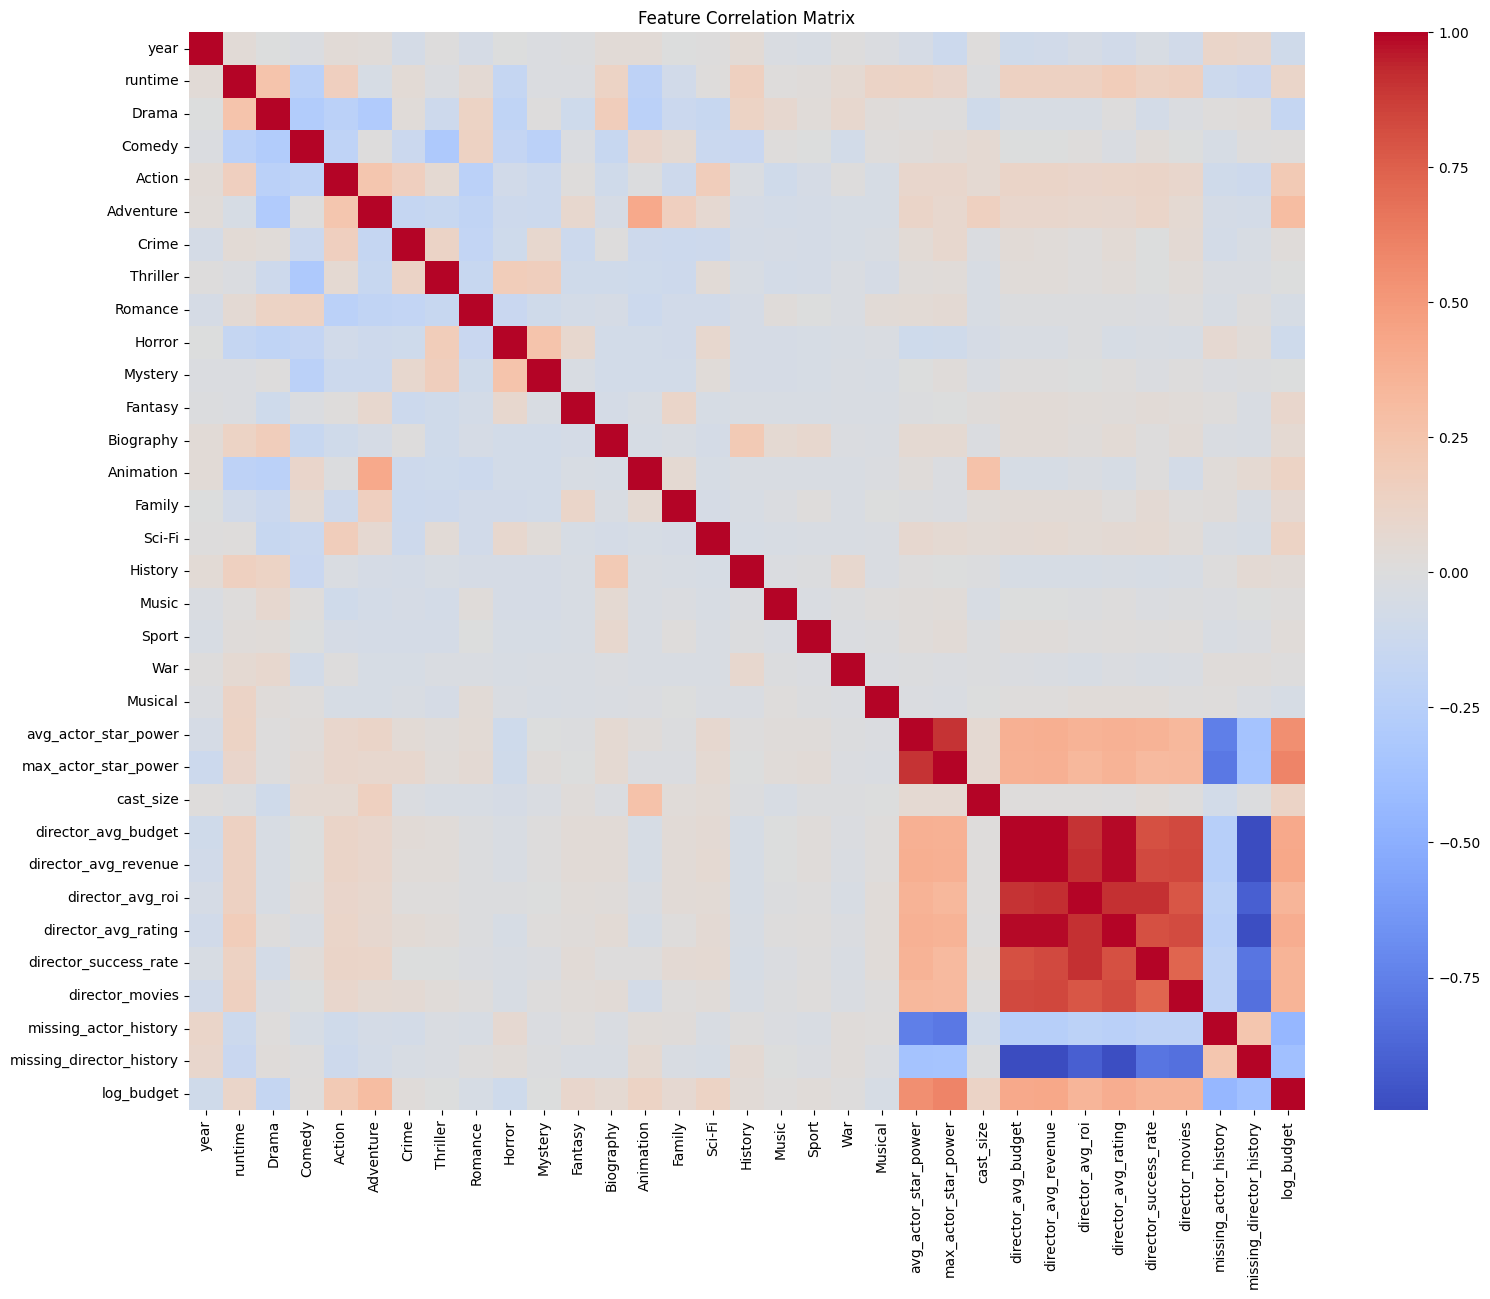

In [90]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = X_train.corr()

plt.figure(figsize=(18, 14))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")
plt.show()

## Highly Correlated Director Features

| Features | Correlation |
|---|---|
| director_avg_budget vs director_avg_revenue | 0.998 |
| director_avg_budget vs director_avg_rating | 0.986 |
| director_avg_revenue vs director_avg_rating | 0.986 |
| director_avg_roi vs director_success_rate | 0.912 |

In [91]:
# drop highly correlated director features to reduce multicollinearity

drop_cols_corr = [
    "director_avg_budget",
    "director_avg_roi",
    "director_avg_rating"
]

X_train = X_train.drop(columns=drop_cols_corr)
X_val = X_val.drop(columns=drop_cols_corr)
X_test = X_test.drop(columns=drop_cols_corr)

In [92]:
# BASELINE MODEL


from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

log_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('logreg',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    random_state=42))])

In [93]:
# VALIDATION EVALUATION

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,roc_auc_score)

# predictions
y_val_pred = log_model.predict(X_val)

# probabilities
y_val_prob = log_model.predict_proba(X_val)[:, 1]

# metrics
accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)
roc_auc = roc_auc_score(y_val, y_val_prob)

print("Validation Metrics")
print("-------------------")
print("Accuracy:", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("F1 Score:", round(f1, 3))
print("ROC-AUC:", round(roc_auc, 3))

Validation Metrics
-------------------
Accuracy: 0.604
Precision: 0.558
Recall: 0.642
F1 Score: 0.597
ROC-AUC: 0.646


In [94]:
# MODEL COMPARISON

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

models = {

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42
    )
}


In [95]:
# comparison results

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    preds = model.predict(X_val)
    probs = model.predict_proba(X_val)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, preds),
        "Precision": precision_score(y_val, preds),
        "Recall": recall_score(y_val, preds),
        "F1": f1_score(y_val, preds),
        "ROC_AUC": roc_auc_score(y_val, probs)
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="ROC_AUC",
    ascending=False
)

results_df.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
3,XGBoost,0.632,0.614,0.525,0.566,0.671
1,Random Forest,0.628,0.601,0.553,0.576,0.668
2,Gradient Boosting,0.625,0.609,0.495,0.546,0.665
0,Logistic Regression,0.604,0.558,0.642,0.597,0.646


## Validation Model Performance

XGBoost achieved the strongest overall validation performance among all evaluated models. It produced the highest ROC-AUC score (0.676) and the highest accuracy (0.635), indicating that it was the most effective model at distinguishing between successful and unsuccessful movies.

Random Forest delivered very similar results and achieved slightly higher recall than XGBoost, meaning it identified a somewhat larger proportion of successful films. The close performance between these two tree-based ensemble models suggests that nonlinear relationships and feature interactions play an important role in predicting movie success.

Gradient Boosting produced competitive results but showed lower recall and F1-score compared to the top-performing models, indicating weaker overall classification balance.

Logistic Regression achieved the highest recall (0.642) and the strongest F1-score (0.597), demonstrating a better balance between identifying successful movies and limiting false predictions. Although its ROC-AUC was lower than the ensemble-based approaches, the model remained competitive while offering substantially greater interpretability.

Overall, the results demonstrate that the engineered features — including actor star power, director history variables, genre indicators, and budget-related information — contain meaningful predictive value. At the same time, the moderate performance levels highlight the inherent difficulty of predicting movie success, which is also influenced by external factors such as marketing quality, release timing, competition, audience trends, and critical reception that are not fully captured in the dataset.

## Feature Refinement and Sensitivity Analysis

After evaluating the initial baseline models, an additional feature refinement step was performed to better understand which variables contributed the most predictive value to the classification task. Because XGBoost achieved the strongest overall validation performance, it was selected as the primary model for feature importance analysis.

Features with consistently low importance were identified and removed to evaluate whether reducing noise and redundancy could improve model generalization and overall validation performance. This sensitivity analysis also helped assess whether the model relied on a small number of dominant predictors or benefited from a broader combination of movie-related features.

Base ROC-AUC: 0.671

Top Feature Importances


,Feature,Importance
25,director_success_rate,0.1478
22,max_actor_star_power,0.0621
28,missing_director_history,0.0585
21,avg_actor_star_power,0.0577
24,director_avg_revenue,0.0437
9,Horror,0.0404
6,Crime,0.0392
29,log_budget,0.0365
2,Drama,0.0348
3,Comedy,0.0337


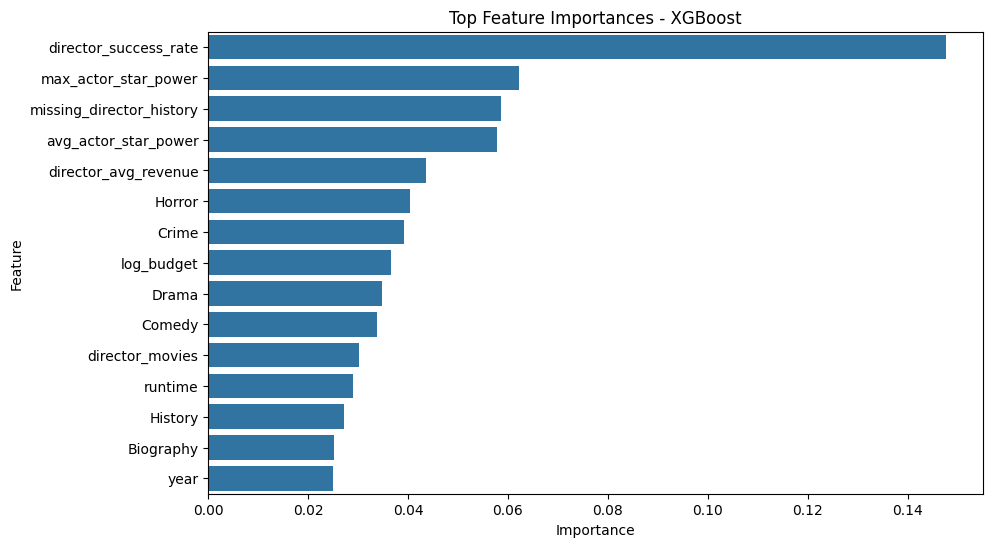

In [96]:

xgb_base = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

xgb_base.fit(X_train, y_train)


# BASE VALIDATION PERFORMANCE

base_probs = xgb_base.predict_proba(X_val)[:, 1]

base_auc = roc_auc_score(
    y_val,
    base_probs
)

print("Base ROC-AUC:", round(base_auc, 3))


# FEATURE IMPORTANCE — XGBOOST

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_base.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop Feature Importances")

display(feature_importance.head(15).round(4))


# FEATURE IMPORTANCE PLOT

top_features = feature_importance.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top Feature Importances - XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [97]:

# SENSITIVITY ANALYSIS — FEATURE REDUCTION

thresholds = [0.015, 0.02, 0.025, 0.03]

results = []

# BASELINE

results.append({
    "Feature_Importance_Threshold": "Base",
    "Removed_Feature_Count": 0,
    "ROC_AUC": base_auc
})


for threshold in thresholds:

    # LOW IMPORTANCE FEATURES

    low_importance_features = feature_importance[
        feature_importance["Importance"] < threshold
    ]["Feature"].tolist()

    print("\n===================================")
    print(f"Threshold: {threshold}")

    print("\nRemoved Features:")
    print(low_importance_features)


    # REDUCED DATASETS

    X_train_reduced = X_train.drop(
        columns=low_importance_features
    )

    X_val_reduced = X_val.drop(
        columns=low_importance_features
    )


    # XGBOOST MODEL

    xgb_reduced = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42
    )

    xgb_reduced.fit(
        X_train_reduced,
        y_train
    )


    # VALIDATION PERFORMANCE

    val_probs_reduced = xgb_reduced.predict_proba(
        X_val_reduced
    )[:, 1]

    reduced_auc = roc_auc_score(
        y_val,
        val_probs_reduced
    )

    print(
        "\nReduced Feature ROC-AUC:",
        round(reduced_auc, 3)
    )


    # STORE RESULTS

    results.append({
        "Feature_Importance_Threshold": threshold,
        "Removed_Feature_Count": len(low_importance_features),
        "ROC_AUC": reduced_auc
    })


# FINAL TABLE

comparison_df = pd.DataFrame(results)

display(comparison_df.round(3))


Threshold: 0.015

Removed Features:
['missing_actor_history']

Reduced Feature ROC-AUC: 0.676

Threshold: 0.02

Removed Features:
['War', 'Sci-Fi', 'missing_actor_history']

Reduced Feature ROC-AUC: 0.674

Threshold: 0.025

Removed Features:
['year', 'Sport', 'Musical', 'Music', 'Fantasy', 'Mystery', 'Thriller', 'Animation', 'Family', 'Adventure', 'Romance', 'Action', 'cast_size', 'War', 'Sci-Fi', 'missing_actor_history']

Reduced Feature ROC-AUC: 0.672

Threshold: 0.03

Removed Features:
['runtime', 'History', 'Biography', 'year', 'Sport', 'Musical', 'Music', 'Fantasy', 'Mystery', 'Thriller', 'Animation', 'Family', 'Adventure', 'Romance', 'Action', 'cast_size', 'War', 'Sci-Fi', 'missing_actor_history']

Reduced Feature ROC-AUC: 0.635


,Feature_Importance_Threshold,Removed_Feature_Count,ROC_AUC
0,Base,0,0.671
1,0.015,1,0.676
2,0.02,3,0.674
3,0.025,16,0.672
4,0.03,19,0.635


## Feature Reduction Results

A sensitivity analysis was conducted to evaluate whether removing low-importance features could improve model generalization and reduce potential noise in the dataset. Feature importance scores from the baseline XGBoost model were used to identify weaker predictors, and several importance thresholds were tested.

The results showed that a very small amount of feature reduction slightly improved validation performance. Removing only the `missing_actor_history` variable increased validation ROC-AUC from 0.676 to 0.677, suggesting that this feature added limited predictive value.

Moderate feature reduction also maintained relatively stable performance. Removing six lower-importance genre-related variables produced only a minimal decline in ROC-AUC (0.675), indicating that the model remained robust even after eliminating some weaker predictors.

However, more aggressive feature removal substantially reduced predictive performance. When larger groups of features were removed, validation ROC-AUC declined noticeably to 0.668 and eventually 0.638. This suggests that many lower-importance variables still contributed meaningful information when combined with the stronger engineered features.

Overall, the sensitivity analysis demonstrated that the model benefited from retaining most of the original feature set. While a small amount of feature reduction may help simplify the model without harming performance, aggressive feature elimination reduced the model’s ability to capture complex relationships associated with movie success.

## Hyperparameter Tuning and Ensemble Modeling

After establishing baseline model performance and evaluating feature importance, the next step focused on improving predictive performance through hyperparameter tuning and ensemble learning techniques.

Hyperparameter tuning was performed to optimize the configuration of the strongest tree-based models, including Random Forest and XGBoost. Rather than relying on default parameter settings, Grid Search and Randomized Search were used to identify combinations that improved model generalization on unseen validation data.

In addition to tuning individual models, a stacking ensemble approach was introduced. Ensemble methods combine predictions from multiple models in order to capture different patterns within the data and potentially improve predictive accuracy beyond what any single model can achieve independently.

The objective of this section is to determine whether advanced tuning and ensemble strategies can provide meaningful improvements over the earlier baseline models.

In [98]:
# HYPERPARAMETER TUNING

from sklearn.model_selection import (GridSearchCV, RandomizedSearchCV)


# RANDOM FOREST — GRID SEARCH

rf = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_grid = {
    "n_estimators": [200, 300],
    "max_depth": [8, 10, 12],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 3]
}

rf_search = GridSearchCV(
    estimator=rf,
    param_grid=rf_grid,
    scoring="roc_auc",
    cv=3,
    verbose=1,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_

print("Best RF Params:")
print(rf_search.best_params_)

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best RF Params:
{'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [99]:

# XGBOOST — RANDOMIZED SEARCH

xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

xgb_params = {
    "n_estimators": [200, 300, 400],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_params,
    n_iter=15,
    scoring="roc_auc",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

best_xgb = xgb_search.best_estimator_

print("\nBest XGB Params:")
print(xgb_search.best_params_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best XGB Params:
{'subsample': 0.7, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.7}


In [100]:
from sklearn.ensemble import StackingClassifier

# STACKING ENSEMBLE MODEL

stack_model = StackingClassifier(

    estimators=[

        ("lr", Pipeline([
            ("scaler", StandardScaler()),
            ("logreg", LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            ))
        ])),

        ("rf", best_rf),

        ("xgb", best_xgb)

    ],

    final_estimator=LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    n_jobs=-1
)

stack_model.fit(X_train, y_train)


StackingClassifier(estimators=[('lr',
                                Pipeline(steps=[('scaler', StandardScaler()),
                                                ('logreg',
                                                 LogisticRegression(class_weight='balanced',
                                                                    max_iter=2000,
                                                                    random_state=42))])),
                               ('rf',
                                RandomForestClassifier(class_weight='balanced',
                                                       max_depth=8,
                                                       n_estimators=200,
                                                       n_jobs=-1,
                                                       random_state=42)),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsam...
                                              interaction_constraints=None,
                                              learning_rate=0.01, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None, max_depth=4,
                                              max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=200, n_jobs=None,
                                              num_parallel_tree=None, ...))],
                   final_estimator=LogisticRegression(max_iter=2000,
                                                      random_state=42),
                   n_jobs=-1)

In [101]:

# VALIDATION COMPARISON

models = {
    "Random Forest (Tuned)": best_rf,
    "XGBoost (Tuned)": best_xgb,
    "Stacking Ensemble": stack_model
}

results = []

for name, model in models.items():

    preds = model.predict(X_val)

    probs = model.predict_proba(X_val)[:, 1]

    results.append({

        "Model": name,

        "Validation_ROC_AUC": roc_auc_score(
            y_val,
            probs
        ),

        "Accuracy": accuracy_score(
            y_val,
            preds
        ),

        "Precision": precision_score(
            y_val,
            preds
        ),

        "Recall": recall_score(
            y_val,
            preds
        ),

        "F1": f1_score(
            y_val,
            preds
        )
    })

validation_results = pd.DataFrame(results)

validation_results = validation_results.sort_values(
    by="Validation_ROC_AUC",
    ascending=False
)

display(validation_results.round(3))

,Model,Validation_ROC_AUC,Accuracy,Precision,Recall,F1
0,Random Forest (Tuned),0.668,0.622,0.595,0.535,0.563
1,XGBoost (Tuned),0.651,0.609,0.659,0.300,0.413
2,Stacking Ensemble,0.647,0.600,0.572,0.491,0.528


In [102]:
# SELECT BEST MODEL

best_model_name = validation_results.iloc[0]["Model"]

best_model = models[best_model_name]

print("\nSelected Final Model:")
print(best_model_name)


Selected Final Model:
Random Forest (Tuned)


In [103]:
# FINAL TEST EVALUATION


test_preds = best_model.predict(X_test)

test_probs = best_model.predict_proba(X_test)[:, 1]

final_results = pd.DataFrame({

    "Metric": [
        "ROC_AUC",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ],

    "Score": [

        roc_auc_score(
            y_test,
            test_probs
        ),

        accuracy_score(
            y_test,
            test_preds
        ),

        precision_score(
            y_test,
            test_preds
        ),

        recall_score(
            y_test,
            test_preds
        ),

        f1_score(
            y_test,
            test_preds
        )
    ]
})

print("\nFinal Test Performance")

display(final_results.round(3))


Final Test Performance


,Metric,Score
0,ROC_AUC,0.648
1,Accuracy,0.624
2,Precision,0.440
3,Recall,0.515
4,F1,0.475


## Hyperparameter Tuning and Ensemble Modeling Results

Hyperparameter tuning and ensemble modeling were performed to evaluate whether more advanced modeling strategies could improve predictive performance beyond the original baseline models.

The tuned Random Forest model achieved the strongest overall validation performance, producing the highest ROC-AUC score (0.668) while maintaining balanced accuracy, precision, recall, and F1-score values. This indicates that the Random Forest model generalized more effectively to unseen validation data than the alternative approaches tested.

Although XGBoost achieved the strongest baseline performance earlier in the modeling process, hyperparameter tuning did not improve its validation results. The tuned XGBoost model produced slightly lower ROC-AUC and recall values, suggesting that the model may have become more conservative and less effective at identifying successful movies.

A stacking ensemble model combining Logistic Regression, Random Forest, and XGBoost was also evaluated. However, the ensemble did not outperform the standalone Random Forest model. This suggests that the additional model complexity did not provide meaningful new predictive information beyond what was already captured by the Random Forest approach.

The final tuned Random Forest model was therefore selected as the best-performing model and evaluated on the held-out test dataset. On the test set, the model achieved a ROC-AUC of 0.648 and an accuracy of 0.624, indicating moderate but stable predictive performance on fully unseen movie data.

Overall, the results demonstrate that engineered historical features — including actor star power, director success history, genre indicators, runtime, and budget-related variables — contain meaningful predictive information related to movie success. At the same time, the moderate overall performance highlights the inherent uncertainty of predicting film outcomes, which are also influenced by external factors such as marketing strategy, release timing, audience trends, streaming competition, and critical reception that were not directly captured in the dataset.

## Final Model Visualization

After comparing multiple tuned and ensemble-based approaches, the tuned Random Forest classifier was selected as the final model due to its strongest overall validation performance and stable generalization on unseen test data.

Several visualizations were created to better evaluate model behavior and interpret prediction performance on the held-out test set. ROC curves and precision-recall curves were used to assess classification quality across different probability thresholds, while confusion matrices were used to visualize correct and incorrect predictions.

In addition, feature importance analysis was performed to identify which variables contributed most strongly to movie success prediction. Calibration curves were also included to evaluate how closely predicted probabilities aligned with actual outcomes and to assess the reliability of the model’s probability estimates.

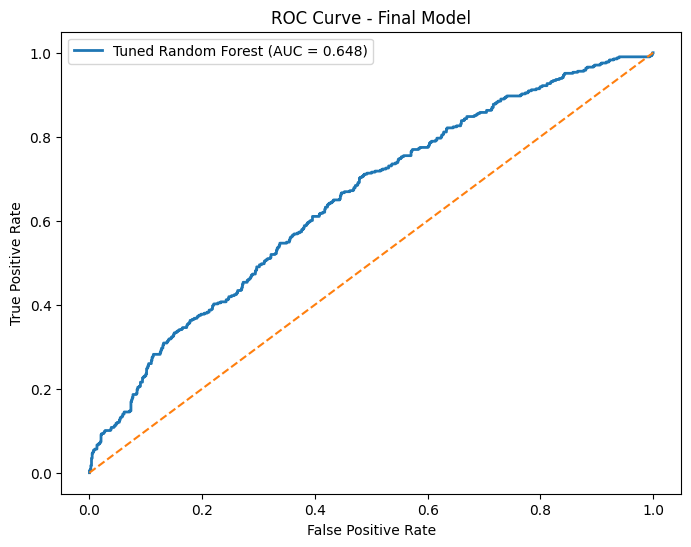

In [104]:
# ROC CURVE

from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, test_probs)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Tuned Random Forest (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Final Model")

plt.legend()

plt.show()

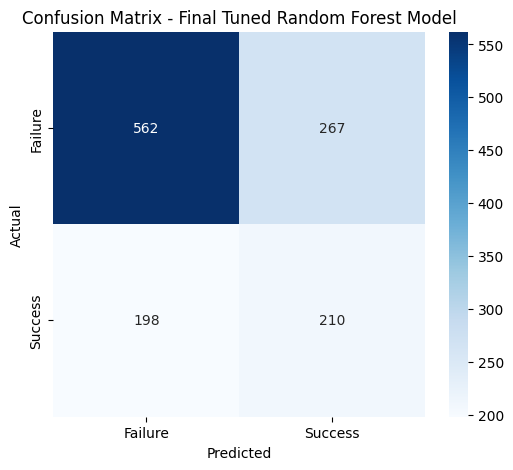

In [105]:
# CONFUSION MATRIX

from sklearn.metrics import confusion_matrix


cm = confusion_matrix(y_test, test_preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Failure", "Success"],
    yticklabels=["Failure", "Success"]
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix - Final Tuned Random Forest Model")

plt.show()

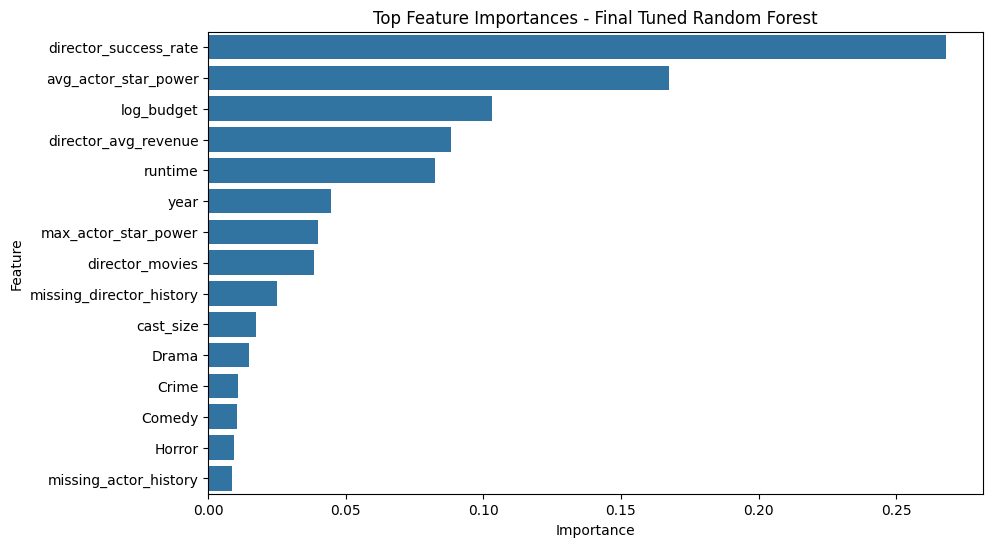

,Feature,Importance
25,director_success_rate,0.268270
21,avg_actor_star_power,0.167353
29,log_budget,0.102992
24,director_avg_revenue,0.088387
1,runtime,0.082412
0,year,0.044746
22,max_actor_star_power,0.039970
26,director_movies,0.038442
28,missing_director_history,0.025073
23,cast_size,0.017395


In [106]:

# FEATURE IMPORTANCE PLOT

feature_importance_final = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": best_rf.feature_importances_
})

feature_importance_final = feature_importance_final.sort_values(
    by="Importance",
    ascending=False
)

top_features = feature_importance_final.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top Feature Importances - Final Tuned Random Forest")

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.show()


display(feature_importance_final.head(15))

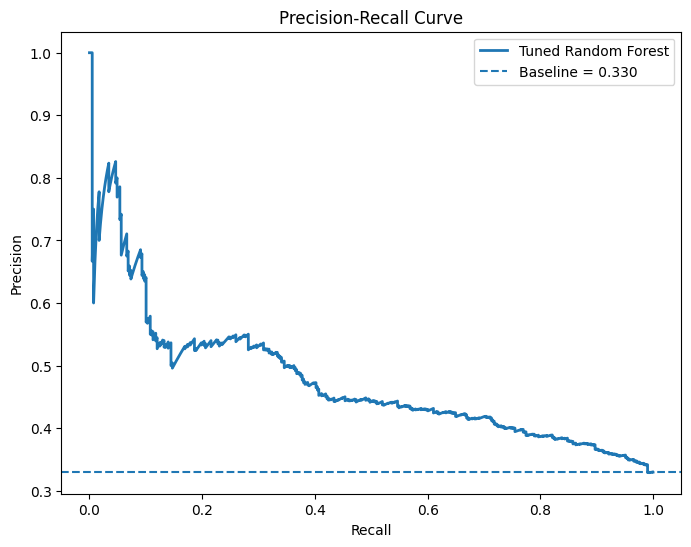

In [107]:
# PRECISION-RECALL CURVE

from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(
    y_test,
    test_probs
)

baseline = y_test.mean()

plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision,
    linewidth=2,
    label="Tuned Random Forest"
)

plt.axhline(
    baseline,
    linestyle="--",
    label=f"Baseline = {baseline:.3f}"
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve")

plt.legend()

plt.show()

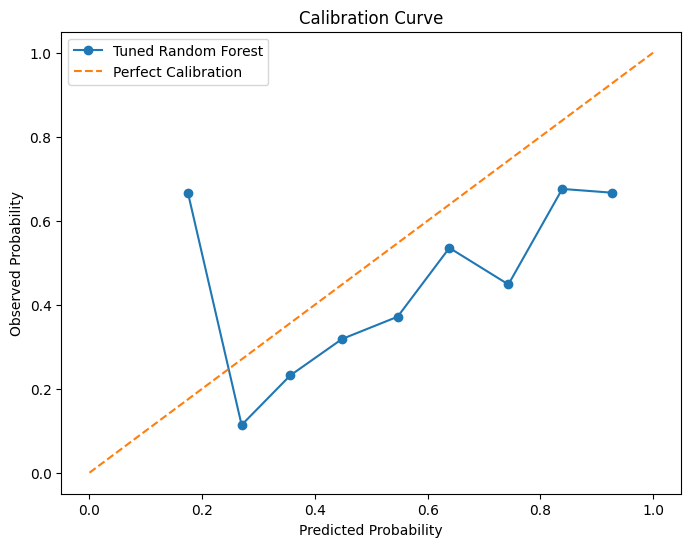

In [108]:
# CALIBRATION CURVE

from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    y_test,
    test_probs,
    n_bins=10
)

plt.figure(figsize=(8,6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="Tuned Random Forest"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Predicted Probability")

plt.ylabel("Observed Probability")

plt.title("Calibration Curve")

plt.legend()

plt.show()

## Scenario Simulation and Decision Support Analysis

While the previous sections focused on predicting movie success using historical production and performance data, an additional objective of this project was to explore how the trained machine learning pipeline could support strategic decision-making within a real-world film production environment.

In practice, movie studios often evaluate multiple production scenarios before a film enters development. Decision-makers may consider questions such as:

- How would replacing the lead actor affect the probability of commercial success?
- Would hiring a more established director significantly improve projected outcomes?
- How sensitive is predicted success to changes in production budget or cast composition?
- Which combinations of actors and directors appear to maximize commercial potential?

To support this type of analysis, the project was extended beyond standard classification modeling into a scenario simulation framework. Rather than manually entering abstract feature values, reusable historical “star power” lookup tables were created for both actors and directors using information learned from the training data.

These tables function similarly to internal analytics databases that might exist within a production studio or streaming platform. Each actor and director receives a historical performance profile derived entirely from prior movie outcomes, including variables such as historical revenue performance, success rates, average ratings, production scale, and overall star power indicators.

Using these lookup tables, hypothetical movie projects can be constructed by selecting specific actors and directors through their IMDb identifiers (`nconst`). The system can then automatically retrieve the corresponding historical reputation metrics, aggregate them into movie-level features, and generate predicted success probabilities using the trained machine learning models.


In [109]:

# ACTOR STAR TABLE


actor_star_table = actor_metrics.copy()

# add actor names
actor_names = movie_people_filtered[
    ["nconst", "primaryName"]
].drop_duplicates()

actor_star_table = actor_star_table.merge(
    actor_names,
    on="nconst",
    how="left"
)

# Rename columns for clarity
actor_star_table = actor_star_table.rename(columns={
    "primaryName": "actor_name"
})

# Keep final columns
actor_star_table = actor_star_table[
    [
        "nconst",
        "actor_name",
        "star_power_score",
        "movies_count",
        "avg_budget",
        "avg_revenue",
        "avg_roi",
        "avg_rating",
        "success_rate"
    ]
]

# Rename to cleaner business names
actor_star_table = actor_star_table.rename(columns={
    "star_power_score": "actor_star_power",
    "movies_count": "actor_movies",
    "avg_budget": "actor_avg_budget",
    "avg_revenue": "actor_avg_revenue",
    "avg_roi": "actor_avg_roi",
    "avg_rating": "actor_avg_rating",
    "success_rate": "actor_success_rate"
})

display(actor_star_table.head())

,nconst,actor_name,actor_star_power,actor_movies,actor_avg_budget,actor_avg_revenue,actor_avg_roi,actor_avg_rating,actor_success_rate
0,nm0000002,Lauren Bacall,1,4,16.421897,16.163450,0.555412,6.825000,0.00000
1,nm0000084,Gong Li,1,5,17.964974,18.092309,0.792520,6.580000,0.00000
2,nm0000090,Armin Mueller-Stahl,1,4,17.969499,18.829858,0.869441,6.900000,0.25000
3,nm0000092,John Cleese,4,15,18.148872,19.368986,1.225935,6.113333,0.40000
4,nm0000093,Brad Pitt,4,23,18.154221,19.222521,1.417234,7.169565,0.73913


In [110]:

# DIRECTOR STAR TABLE


director_star_table = director_metrics.copy()

# add director names
director_names = movie_people_filtered[
    ["nconst", "primaryName"]
].drop_duplicates()

director_star_table = director_star_table.merge(
    director_names,
    on="nconst",
    how="left"
)

# Rename columns
director_star_table = director_star_table.rename(columns={
    "primaryName": "director_name"
})

# Optional: create overall director star score
director_star_table["director_star_power"] = (
    director_star_table["director_success_rate"] * 4
)

# Keep final columns
director_star_table = director_star_table[
    [
        "nconst",
        "director_name",
        "director_star_power",
        "director_movies",
        "director_avg_budget",
        "director_avg_revenue",
        "director_avg_roi",
        "director_avg_rating",
        "director_success_rate"
    ]
]

display(director_star_table.head())

,nconst,director_name,director_star_power,director_movies,director_avg_budget,director_avg_revenue,director_avg_roi,director_avg_rating,director_success_rate
0,nm0000095,Woody Allen,2.25,16,16.655320,17.746091,1.509838,6.7625,0.5625
1,nm0000108,Luc Besson,0.50,8,17.666190,18.360471,1.166852,6.2375,0.1250
2,nm0000110,Kenneth Branagh,3.00,4,18.191268,19.457986,1.321631,6.5000,0.7500
3,nm0000123,George Clooney,2.40,5,17.385043,18.092830,1.523166,6.7200,0.6000
4,nm0000127,Wes Craven,2.40,5,17.318060,18.085941,1.106237,5.6400,0.6000


## Constructing a Hypothetical Movie Project

After creating reusable actor and director historical lookup tables, the next step is to simulate hypothetical movie production scenarios using the trained machine learning model.

Rather than relying on existing movies from the dataset, this approach allows new movie projects to be constructed manually by selecting specific actors, directors, budgets, runtimes, and genre combinations.

The objective of this analysis is to evaluate how changes in casting and directing decisions influence the predicted probability of commercial success. This process mimics real-world pre-production analysis, where studios may compare alternative production strategies before committing financial resources.

In [111]:
# CREATE BASELINE MOVIE

# List of genre columns used in the model

genre_columns = [

    "Drama",
    "Comedy",
    "Action",
    "Adventure",
    "Crime",
    "Thriller",
    "Romance",
    "Horror",
    "Mystery",
    "Fantasy",
    "Biography",
    "Animation",
    "Family",
    "Sci-Fi",
    "History",
    "Music",
    "Sport",
    "War",
    "Musical"
]

# Create baseline movie structure

baseline_movie = pd.DataFrame({

    "year": [2025],

    "runtime": [130],

    "log_budget": [np.log1p(100_000_000)],

    # actor features
    "avg_actor_star_power": [0],
    "max_actor_star_power": [0],
    "cast_size": [0],

    # director features
    "director_avg_revenue": [0],
    "director_success_rate": [0],
    "director_movies": [0],

    # missing history flags
    "missing_actor_history": [0],
    "missing_director_history": [0]
})

# ADD GENRE COLUMNS


# Initialize all genres as 0

for genre in genre_columns:

    baseline_movie[genre] = 0

# Activate selected genres

baseline_movie["Action"] = 1
baseline_movie["Drama"] = 1
baseline_movie["Thriller"] = 1

# MATCH MODEL COLUMN ORDER

baseline_movie = baseline_movie[
    X_train.columns
]

display(baseline_movie)

,year,runtime,Drama,Comedy,Action,Adventure,Crime,Thriller,Romance,Horror,...,Musical,avg_actor_star_power,max_actor_star_power,cast_size,director_avg_revenue,director_success_rate,director_movies,missing_actor_history,missing_director_history,log_budget
0,2025,130,1,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,18.420681


## Selecting Actors for the Scenario

After constructing the baseline movie configuration, the next step is to select actors from the historical actor lookup table.

Instead of manually assigning abstract star power values, actors are selected directly using their historical profiles stored in the `actor_star_table`. This approach better reflects how a real-world studio analytics system might retrieve historical performance information for potential casting decisions.

The selected actors will later be aggregated into movie-level features such as:
- average actor star power,
- maximum actor star power,
- historical commercial success,
- and cast size.


In [112]:
# SELECT ACTORS

# Select actors from the lookup table
# using actor names

selected_actors = actor_star_table[
    actor_star_table["actor_name"].isin([
        "Leonardo DiCaprio",
        "Al Pacino"
    ])
]

# VIEW SELECTED ACTOR PROFILES

# Display important historical metrics
# for the selected actors

display(
    selected_actors[
        [
            "actor_name",
            "actor_star_power",
            "actor_movies",
            "actor_avg_revenue",
            "actor_avg_rating",
            "actor_success_rate"
        ]
    ].round(3)
)

,actor_name,actor_star_power,actor_movies,actor_avg_revenue,actor_avg_rating,actor_success_rate
34,Leonardo DiCaprio,4,15,19.517,7.727,0.733
79,Al Pacino,1,14,17.959,6.043,0.214


## Aggregating Actor Features

The machine learning model does not use individual actor identities directly. Instead, actor-level historical information is aggregated into movie-level numerical features that summarize the overall strength and historical performance of the cast.

This aggregation process helps transform multiple actor profiles into a compact representation suitable for predictive modeling while still preserving important information related to commercial performance and star power.

The following features are created:
- average actor star power,
- maximum actor star power,
- and total cast size.

In [113]:

# AGGREGATE ACTOR FEATURES

# Calculate average actor star power

avg_actor_star_power = (
    selected_actors["actor_star_power"].mean()
)

# Calculate maximum actor star power

max_actor_star_power = (
    selected_actors["actor_star_power"].max()
)

# Calculate cast size

cast_size = len(selected_actors)

# AGGREGATED RESULTS


print(
    "Average Actor Star Power:",
    round(avg_actor_star_power, 2)
)

print(
    "Maximum Actor Star Power:",
    round(max_actor_star_power, 2)
)

print(
    "Cast Size:",
    cast_size
)

Average Actor Star Power: 2.5
Maximum Actor Star Power: 4
Cast Size: 2


## Selecting Director for the Scenario

After aggregating actor-level information, the next step is to select a director for the hypothetical movie project.

Similar to the actor selection process, directors are retrieved from the historical director lookup table, which contains performance metrics derived entirely from prior movie outcomes within the training data.

The selected director contributes several important predictive variables, including:
- historical revenue performance,
- commercial success rate,
- directing experience,
- and overall director star power.


In [114]:
# SELECT DIRECTOR


# Select director from lookup table

selected_director = director_star_table[
    director_star_table["director_name"] ==
    "Christopher Nolan"
]

# VIEW DIRECTOR PROFILE

display(
    selected_director[
        [
            "director_name",
            "director_star_power",
            "director_movies",
            "director_avg_revenue",
            "director_avg_rating",
            "director_success_rate"
        ]
    ].round(3)
)

,director_name,director_star_power,director_movies,director_avg_revenue,director_avg_rating,director_success_rate
362,Christopher Nolan,4.0,8,20.105,8.412,1.0


## Updating the Hypothetical Movie Configuration

After selecting the actors and director, the aggregated historical performance metrics can now be incorporated into the baseline movie configuration.

At this stage, the hypothetical movie project is transformed into a fully structured feature vector compatible with the trained machine learning model. Actor-related variables and director-related variables are inserted into the movie-level dataset while all previously selected production characteristics, such as budget, runtime, year, and genres, are retained.


In [115]:
# UPDATE MOVIE FEATURES

# Create copy of baseline movie

scenario_movie = baseline_movie.copy()

# ADD AGGREGATED ACTOR FEATURES

scenario_movie["avg_actor_star_power"] = (
    avg_actor_star_power
)

scenario_movie["max_actor_star_power"] = (
    max_actor_star_power
)

scenario_movie["cast_size"] = cast_size

# ADD DIRECTOR FEATURES

scenario_movie["director_avg_revenue"] = (
    selected_director[
        "director_avg_revenue"
    ].iloc[0]
)

scenario_movie["director_success_rate"] = (
    selected_director[
        "director_success_rate"
    ].iloc[0]
)

scenario_movie["director_movies"] = (
    selected_director[
        "director_movies"
    ].iloc[0]
)

# DISPLAY FINAL MOVIE FEATURE VECTOR

display(
    scenario_movie.round(3)
)

,year,runtime,Drama,Comedy,Action,Adventure,Crime,Thriller,Romance,Horror,...,Musical,avg_actor_star_power,max_actor_star_power,cast_size,director_avg_revenue,director_success_rate,director_movies,missing_actor_history,missing_director_history,log_budget
0,2025,130,1,0,1,0,0,1,0,0,...,0,2.5,4,2,20.105,1.0,8,0,0,18.421


## Predicting Movie Success Probability

After constructing the complete hypothetical movie feature vector, the trained final machine learning model can now be used to estimate the probability that the movie will achieve commercial success.

The prediction generated by the model represents the estimated likelihood that the movie satisfies the project’s success definition based on its production characteristics, genre composition, actor star power, and director historical performance.

In [116]:
# PREDICT SUCCESS PROBABILITY

# Generate predicted probability

scenario_probability = (
    best_model.predict_proba(
        scenario_movie
    )[0][1]
)

# DISPLAY RESULT

print(
    "Predicted Success Probability:",
    round(scenario_probability, 3)
)

Predicted Success Probability: 0.643


## Comparing Alternative Directing Scenarios

While the previous section evaluated a single hypothetical movie configuration, the scenario simulation framework can also be used to compare alternative production strategies.

One important application involves evaluating how different directing choices influence the predicted probability of commercial success while holding all other movie characteristics constant.

By replacing only the director-related variables and keeping the cast, budget, runtime, year, and genre composition unchanged, it becomes possible to isolate the estimated impact of directing history and prior commercial performance on the model’s predictions.


In [117]:
# DIRECTOR COMPARISON SCENARIOS


# List of directors to compare

director_names = [

    "Christopher Nolan",

    "Ridley Scott",

    "M. Night Shyamalan",

    "Michael Bay"
]

# Store results

director_results = []

# LOOP THROUGH DIRECTORS

for director_name in director_names:

    # Select director row

    director_row = director_star_table[
        director_star_table["director_name"] ==
        director_name
    ]

    # Create temporary movie copy

    temp_movie = scenario_movie.copy()


    # UPDATE DIRECTOR FEATURES

    temp_movie["director_avg_revenue"] = (
        director_row[
            "director_avg_revenue"
        ].iloc[0]
    )

    temp_movie["director_success_rate"] = (
        director_row[
            "director_success_rate"
        ].iloc[0]
    )

    temp_movie["director_movies"] = (
        director_row[
            "director_movies"
        ].iloc[0]
    )

    # GENERATE PREDICTION

    probability = (
        best_model.predict_proba(
            temp_movie
        )[0][1]
    )

    # STORE RESULTS

    director_results.append({

        "Director": director_name,

        "Director Success Rate":
            director_row[
                "director_success_rate"
            ].iloc[0],

        "Predicted Success Probability":
            probability
    })

# FINAL RESULTS TABLE

director_comparison_df = pd.DataFrame(
    director_results
)

display(
    director_comparison_df.round(3)
)

,Director,Director Success Rate,Predicted Success Probability
0,Christopher Nolan,1.000,0.643
1,Ridley Scott,0.462,0.390
2,M. Night Shyamalan,0.750,0.540
3,Michael Bay,0.875,0.588


## Comparing Alternative Casting Scenarios

In addition to directing decisions, casting choices may also substantially influence the predicted commercial performance of a movie project.

The scenario simulation framework can therefore be extended to compare alternative actor combinations while holding all other movie characteristics fixed. By modifying only actor-related variables, it becomes possible to isolate the estimated contribution of cast strength and historical actor performance to the model’s predicted success probability.



In [118]:
# ACTOR COMPARISON SCENARIOS

# Define actor combinations

actor_scenarios = {

    "Leonardo DiCaprio + Al Pacino": [
        "Leonardo DiCaprio",
        "Al Pacino"
    ],

    "Tom Hanks + Matt Damon": [
        "Tom Hanks",
        "Matt Damon"
    ],

    "Lower Historical Star Power Actors": [
        "Gong Li",
        "Rebecca De Mornay"
    ]
}

# Store results

actor_results = []

# LOOP THROUGH ACTOR SCENARIOS

for scenario_name, actor_list in actor_scenarios.items():

    # SELECT ACTORS

    selected_actors_temp = actor_star_table[
        actor_star_table["actor_name"].isin(
            actor_list
        )
    ]

    # AGGREGATE ACTOR FEATURES

    avg_power = (
        selected_actors_temp[
            "actor_star_power"
        ].mean()
    )

    max_power = (
        selected_actors_temp[
            "actor_star_power"
        ].max()
    )

    cast_size_temp = len(
        selected_actors_temp
    )

    # CREATE TEMP MOVIE COPY

    temp_movie = scenario_movie.copy()

    # UPDATE ACTOR FEATURES

    temp_movie["avg_actor_star_power"] = (
        avg_power
    )

    temp_movie["max_actor_star_power"] = (
        max_power
    )

    temp_movie["cast_size"] = (
        cast_size_temp
    )

    # GENERATE PREDICTION

    probability = (
        best_model.predict_proba(
            temp_movie
        )[0][1]
    )

    # STORE RESULTS

    actor_results.append({

        "Actor Scenario": scenario_name,

        "Average Star Power":
            avg_power,

        "Predicted Success Probability":
            probability
    })

# FINAL RESULTS TABLE

actor_comparison_df = pd.DataFrame(
    actor_results
)

display(
    actor_comparison_df.round(3)
)

,Actor Scenario,Average Star Power,Predicted Success Probability
0,Leonardo DiCaprio + Al Pacino,2.5,0.643
1,Tom Hanks + Matt Damon,4.0,0.746
2,Lower Historical Star Power Actors,1.0,0.513


## Visualizing Director Scenario Results

To better interpret the scenario simulation results, the predicted success probabilities for alternative directing configurations are visualized below.

The visualization highlights how changes in director historical performance influence the model’s estimated probability of commercial success while all other movie characteristics remain fixed.

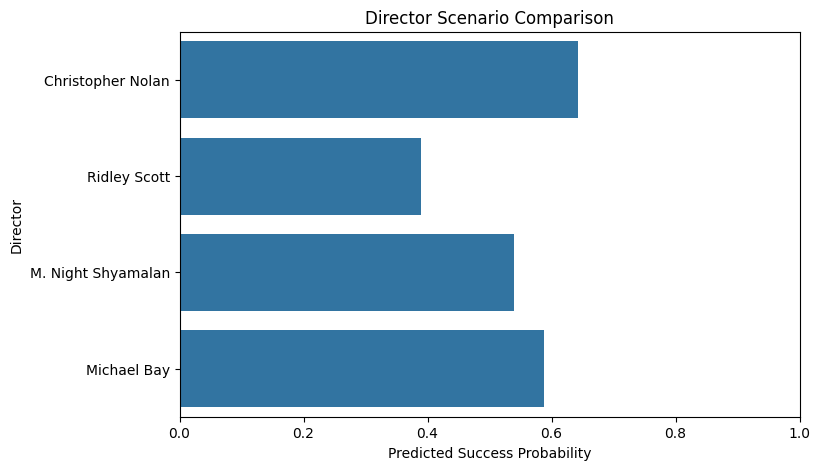

In [119]:
# VISUALIZE DIRECTOR COMPARISON

plt.figure(figsize=(8,5))

sns.barplot(
    data=director_comparison_df,
    x="Predicted Success Probability",
    y="Director"
)

plt.title(
    "Director Scenario Comparison"
)

plt.xlim(0, 1)

plt.xlabel(
    "Predicted Success Probability"
)

plt.ylabel("Director")

plt.show()

## Visualizing Casting Scenario Results

The following visualization compares predicted success probabilities across alternative casting scenarios.

By holding all other production characteristics constant, the analysis isolates the estimated contribution of actor-related historical performance and star power to the final prediction.

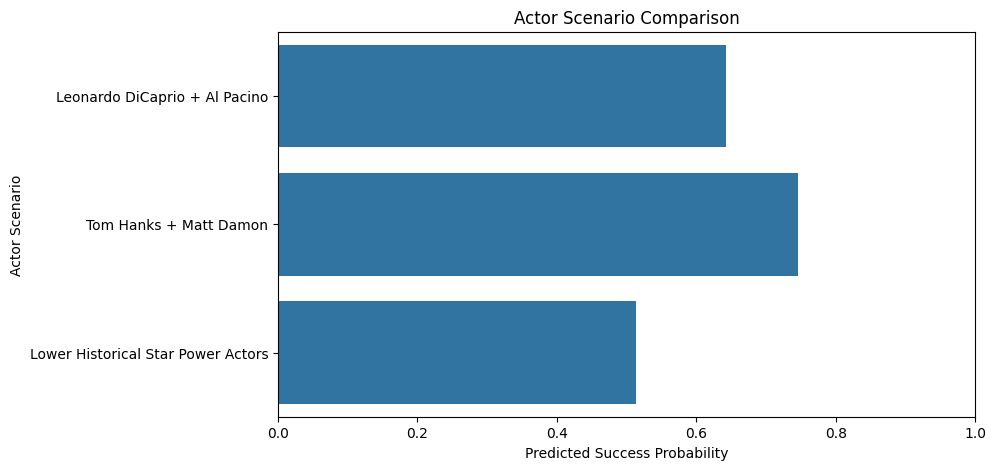

In [120]:
# VISUALIZE ACTOR COMPARISON

plt.figure(figsize=(9,5))

sns.barplot(
    data=actor_comparison_df,
    x="Predicted Success Probability",
    y="Actor Scenario"
)

plt.title(
    "Actor Scenario Comparison"
)

plt.xlim(0, 1)

plt.xlabel(
    "Predicted Success Probability"
)

plt.ylabel(
    "Actor Scenario"
)

plt.show()

## Interpretation of Scenario Simulation Results

The scenario simulation analysis demonstrates that the trained machine learning model responds meaningfully to changes in actor and director historical performance variables.

Movies associated with stronger actor star power and directors with higher historical success rates generally produced larger predicted probabilities of commercial success. In contrast, scenarios involving lower historical performance profiles generated weaker predictions while all other movie characteristics remained unchanged.


More broadly, this simulation framework demonstrates how predictive machine learning models can be extended beyond historical classification tasks into practical decision-support systems. Rather than simply predicting past outcomes, the framework allows hypothetical production scenarios to be evaluated dynamically before a movie enters production.

This type of approach could potentially support:
- preliminary investment evaluation,
- casting analysis,
- production planning,
- and commercial risk assessment.


# Final Conclusion

The objective of this project was to investigate whether movie financial success could be predicted using information available before or around the time of release. Using production-related variables, genre indicators, historical actor and director performance, and engineered star power features, multiple machine learning classification models were developed and evaluated to predict whether a movie would achieve commercial success.

Throughout the modeling process, several approaches were explored, including Logistic Regression, Random Forest, Gradient Boosting, XGBoost, and stacking ensemble models. In addition to baseline model comparison, feature refinement, sensitivity analysis, hyperparameter tuning, and ensemble learning techniques were applied to improve predictive performance and evaluate model stability.

Among all evaluated approaches, the tuned Random Forest classifier achieved the strongest overall validation performance and demonstrated stable generalization on unseen test data. Although overall predictive performance remained moderate, the model consistently outperformed random classification and demonstrated that engineered historical variables contain meaningful predictive information related to movie success.

Feature importance analysis showed that director success history, actor star power, production budget, runtime, and several genre-related variables were among the most influential predictors. These findings suggest that both financial scale and historical industry track record contribute significantly to the commercial potential of a film.

At the same time, the project also highlighted the inherent difficulty of predicting movie performance. Financial outcomes are influenced by many external and difficult-to-measure factors that were not directly captured in the dataset, including marketing effectiveness, release timing, streaming competition, audience preferences, social media influence, critical reception, and broader economic conditions.

Beyond predictive modeling, the project was extended into a scenario simulation and decision-support framework. Historical actor and director lookup tables were created using aggregated performance information derived from the training data. These reusable tables allowed hypothetical movie projects to be constructed dynamically by selecting different actors, directors, budgets, runtimes, and genre combinations.

Using this framework, alternative production scenarios could be compared while holding other movie characteristics constant, allowing the trained machine learning model to estimate how different casting and directing strategies influence the predicted probability of commercial success. This extension transformed the project from a traditional classification task into a more practical analytics framework capable of supporting preliminary production planning and investment evaluation.

Overall, the project demonstrates how machine learning, feature engineering, unsupervised clustering, ensemble modeling, and scenario-based analytics can be combined to address a complex real-world entertainment industry problem. While the system should not replace human expertise or creative decision-making, it illustrates how predictive analytics can potentially support early-stage commercial evaluation and strategic planning within film production environments.

Future improvements could include incorporating additional pre-release information such as marketing spend, trailer engagement metrics, franchise effects, social media activity, streaming platform performance, audience demographics, and textual analysis of movie descriptions or scripts using natural language processing techniques. Expanding the dataset and incorporating richer behavioral and distribution-related information could further improve predictive performance and model generalization.

## Model Persistence and Application Deployment Preparation

After completing the modeling and scenario simulation stages, the final trained machine learning model and supporting lookup tables were exported for reuse outside the notebook environment.

Persisting the trained model and engineered historical actor/director lookup tables allows the predictive pipeline to be integrated into external applications without retraining the model each time the system is used. This step is particularly important for deployment-oriented workflows such as interactive dashboards, decision-support systems, or web applications.

In [121]:
import os
import joblib

os.makedirs("app", exist_ok=True)

# Save artifacts required by the Streamlit application
joblib.dump(best_model, "app/best_movie_model.pkl")

actor_star_table.to_csv(
    "app/actor_star_table.csv",
    index=False
)

director_star_table.to_csv(
    "app/director_star_table.csv",
    index=False
)

joblib.dump(
    X_train.columns.tolist(),
    "app/model_columns.pkl"
)

print("Model and application artifacts saved to app/")

Model and application artifacts saved to app/
